# YNACC and IAC Dataset Preparation

In [3]:
from jsonl_from_tsv import convert_tsv_to_jsonl
import pandas as pd

In [2]:
import pandas as pd

# Assuming your file path is correct based on your previous code
df = pd.read_csv(
    "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv",
    sep="\t",
)

print(f"Total length of DataFrame: {len(df)}")

# Get value counts, including NA/NaN values
constructive_class_counts = df["constructiveclass"].value_counts(dropna=False)
print("\nValue Counts (including NA):")
print(constructive_class_counts)

# Calculate the sum of these counts
sum_of_counts = constructive_class_counts.sum()
print(f"\nSum of value counts: {sum_of_counts}")

# You can also directly count the missing values
missing_values_count = df["constructiveclass"].isnull().sum()
print(f"Number of missing values (NaN/NA): {missing_values_count}")

# Verify the sum
print(f"Verification: {sum_of_counts} == {len(df)}")

Total length of DataFrame: 22536

Value Counts (including NA):
constructiveclass
Constructive        16010
Not constructive     5392
NaN                  1129
Something Else          5
Name: count, dtype: int64

Sum of value counts: 22536
Number of missing values (NaN/NA): 1129
Verification: 22536 == 22536


In [3]:
import pandas as pd
import numpy as np  # For np.nan

# Define your input path
input_path = "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_turk_annotations.tsv"

try:
    # Read the TSV file, preventing pandas from interpreting 'NA' as NaN by default.
    # keep_default_na=False ensures that common strings like 'NA', '', '#N/A' etc.,
    # are NOT treated as NaN unless explicitly listed in na_values.
    # We also set na_values=[] to ensure no strings are converted to NaN.
    df_raw = pd.read_csv(
        input_path,
        sep="\t",
        keep_default_na=False,  # Important: Do not convert default missing value strings
        na_values=[],  # Important: Do not convert any specified values to NaN
    )

    print(f"Total length of DataFrame: {len(df_raw)}")

    # Get the 'constructiveclass' column
    constructive_class_series = df_raw["constructiveclass"]

    print("\n--- Value Counts with distinct NA/NaN ---")
    # Use value_counts(dropna=False) to count everything, including actual NaN/None
    # This will now differentiate between the string 'NA' and actual missing values
    # (represented as np.nan or None by pandas for truly empty cells after loading)
    all_distinct_counts = constructive_class_series.value_counts(dropna=False)
    print(all_distinct_counts)

    print("\n--- Further Breakdown ---")
    # Count how many are the string 'NA'
    count_string_na = (constructive_class_series == "NA").sum()
    print(f"Count of cells containing the string 'NA': {count_string_na}")

    # Count how many are actual pandas NaN values (from truly empty cells or other non-recognized missing markers)
    count_string_nan = (constructive_class_series == "NaN").sum()
    print(f"Count of cells containing the string 'NaN': {count_string_nan}")

    # Verify the sum
    total_sum_of_counts = all_distinct_counts.sum()
    print(f"\nSum of all distinct counts: {total_sum_of_counts}")
    print(
        f"Does sum of counts match DataFrame length? {total_sum_of_counts == len(df_raw)}"
    )

except FileNotFoundError:
    print(f"Error: The file '{input_path}' was not found. Please check the path.")
    # You might want to create a dummy DataFrame for testing here
    # For example:
    # data = {'constructiveclass': ['Constructive', 'Not constructive', 'NA', '', 'Constructive', 'NA', np.nan, 'Not constructive', None]}
    # df_raw = pd.DataFrame(data)
    # print("Using a dummy DataFrame for demonstration due to FileNotFoundError.")
    # Then re-run the counting logic on df_raw

Total length of DataFrame: 25532

--- Value Counts with distinct NA/NaN ---
constructiveclass
Constructive        12236
Not constructive    12191
NaN                  1105
Name: count, dtype: int64

--- Further Breakdown ---
Count of cells containing the string 'NA': 0
Count of cells containing the string 'NaN': 1105

Sum of all distinct counts: 25532
Does sum of counts match DataFrame length? True


In [ ]:
# Preprocess the YNACC dataset expert annotations
input_data_path = [
    "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv",
    "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_turk_annotations.tsv",
]
output_data_path = "../training_data/ynacc_processed.jsonl"

convert_tsv_to_jsonl(input_data_path, output_data_path)

Reading ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv and normalizing 'NaN' and 'NA' to 'NA' string...
Processing line 0 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 1000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 2000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 3000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 4000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 5000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 6000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 7000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Processing line 8000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_expert_annotations.tsv...
Proce

Processing threads and writing JSONL: 100%|██████████| 2400/2400 [00:00<00:00, 44307.59it/s]


--- Majority Voting Summary ---
Total threads with 'NA' annotations (skipped): 338
Threads skipped (all annotations were 'NA'): 0
Threads skipped (tie in non-'NA' labels only): 180
Threads skipped (tie between 'NA' and a constructive label): 0
Threads resolved (NA was overall top, but non-NA label existed): 0
Threads resolved (clear non-'NA' majority): 1882
Total threads attempted to resolve: 2400
Max author number across all threads: 14
Processed data written to ../data/ynacc_processed.jsonl


In [ ]:
input_data_path = [
    "../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv",
]
output_data_path = "../training_data/iac_processed.jsonl"

convert_tsv_to_jsonl(input_data_path, output_data_path)

Reading ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv and normalizing 'NaN' and 'NA' to 'NA' string...
Processing line 0 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 1000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 2000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 3000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 4000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 5000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 6000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 7000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 8000 from ../dataset/ydata-ynacc-v1_0/ydata-ynacc-v1_0_IAC_annotations.tsv...
Processing line 9000 from ../datase

Processing threads and writing JSONL: 100%|██████████| 986/986 [00:00<00:00, 39501.63it/s]


--- Majority Voting Summary ---
Total threads with 'NA' annotations (skipped): 217
Threads skipped (all annotations were 'NA'): 0
Threads skipped (tie in non-'NA' labels only): 0
Threads skipped (tie between 'NA' and a constructive label): 0
Threads resolved (NA was overall top, but non-NA label existed): 0
Threads resolved (clear non-'NA' majority): 769
Total threads attempted to resolve: 986
Max author number across all threads: 18
Processed data written to ../data/iac_processed.jsonl


In [3]:
import json
import pandas as pd
from transformers import BertTokenizerFast
import numpy as np
import matplotlib.pyplot as plt
import os


def analyze_token_distribution(jsonl_file_path, model_name="bert-base-uncased"):
    """
    Reads a JSONL file, tokenizes the 'text' field using a BERT tokenizer,
    and analyzes the distribution of token counts.

    Args:
        jsonl_file_path (str): Path to the input JSONL file.
        model_name (str): The name of the pre-trained BERT model to use for tokenization.
    """
    print(f"Loading data from {jsonl_file_path}...")
    data = []
    try:
        with open(jsonl_file_path, "r", encoding="utf-8") as f:
            for line in f:
                data.append(json.loads(line))
    except FileNotFoundError:
        print(
            f"Error: JSONL data file not found at {jsonl_file_path}. Please check the path."
        )
        return

    if not data:
        print("No data loaded. Exiting analysis.")
        return

    df = pd.DataFrame(data)
    print(f"Successfully loaded {len(df)} entries.")

    print(f"Initializing tokenizer for '{model_name}'...")
    tokenizer = BertTokenizerFast.from_pretrained(model_name)

    token_counts = []
    print("Tokenizing texts and counting tokens (this might take a moment)...")
    for index, row in df.iterrows():
        # Tokenize without truncation to get the actual full length
        encoding = tokenizer.encode_plus(
            str(row["text"]),
            add_special_tokens=True,
            return_token_type_ids=False,
            return_attention_mask=False,
            truncation=False,  # IMPORTANT: Do not truncate here, we want actual length
        )
        token_counts.append(len(encoding["input_ids"]))

    token_counts_np = np.array(token_counts)

    print("\n--- Token Count Distribution ---")
    print(f"Total threads: {len(token_counts_np)}")
    print(f"Minimum tokens: {np.min(token_counts_np)}")
    print(f"Maximum tokens: {np.max(token_counts_np)}")
    print(f"Mean tokens: {np.mean(token_counts_np):.2f}")
    print(f"Median tokens: {np.median(token_counts_np)}")
    print(f"Standard deviation: {np.std(token_counts_np):.2f}")

    print("\n--- Percentiles ---")
    percentiles = [50, 75, 90, 95, 99, 100]  # Include 100th for max
    for p in percentiles:
        val = np.percentile(token_counts_np, p)
        print(f"{p}th percentile: {int(val)} tokens")

    # Calculate proportion of threads above 512 tokens
    above_512 = np.sum(token_counts_np > 512)
    proportion_above_512 = (above_512 / len(token_counts_np)) * 100
    print(
        f"\nThreads with more than 512 tokens: {above_512} ({proportion_above_512:.2f}%)"
    )

    # Optional: Plotting a histogram
    print("\nAttempting to plot histogram (requires matplotlib)...")
    try:
        plt.figure(figsize=(12, 6))
        plt.hist(token_counts_np, bins=50, color="skyblue", edgecolor="black")
        plt.title("Distribution of Token Counts per Thread")
        plt.xlabel(f"Number of Tokens ({model_name} Tokenizer)")
        plt.ylabel("Number of Threads")
        plt.axvline(x=512, color="red", linestyle="--", label="BERT Max Length (512)")
        plt.legend()
        plt.grid(axis="y", alpha=0.75)
        plt.show()
        print("Histogram displayed successfully.")
    except Exception as e:
        print(f"Could not plot histogram. Error: {e}")
        print("Please ensure 'matplotlib' is installed (`pip install matplotlib`)")

/home/niklas/local_files/env/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading data from ../data/ynacc_processed.jsonl...
Successfully loaded 1882 entries.
Initializing tokenizer for 'bert-base-uncased'...


Token indices sequence length is longer than the specified maximum sequence length for this model (767 > 512). Running this sequence through the model will result in indexing errors


Tokenizing texts and counting tokens (this might take a moment)...

--- Token Count Distribution ---
Total threads: 1882
Minimum tokens: 28
Maximum tokens: 4401
Mean tokens: 421.49
Median tokens: 330.0
Standard deviation: 337.02

--- Percentiles ---
50th percentile: 330 tokens
75th percentile: 550 tokens
90th percentile: 802 tokens
95th percentile: 985 tokens
99th percentile: 1623 tokens
100th percentile: 4401 tokens

Threads with more than 512 tokens: 526 (27.95%)

Attempting to plot histogram (requires matplotlib)...


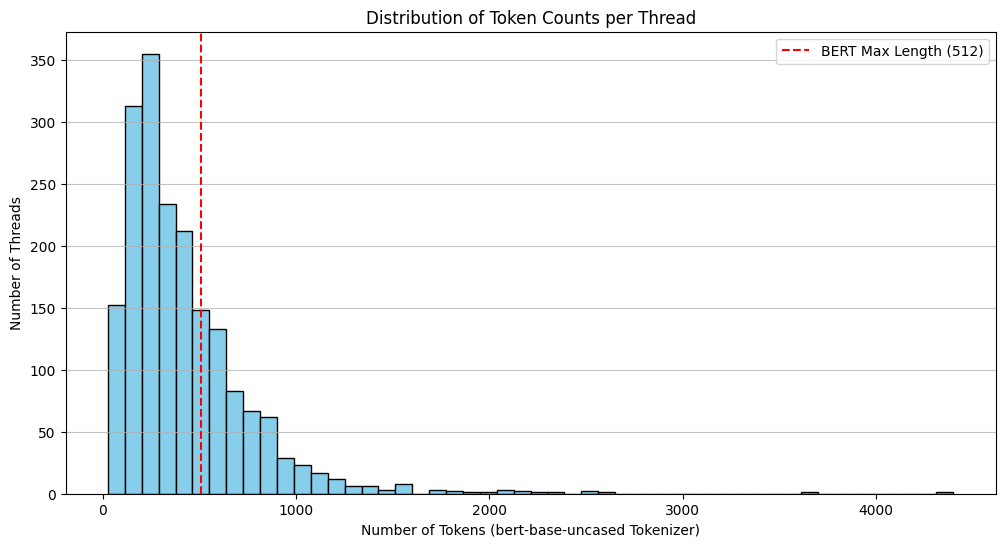

Histogram displayed successfully.


In [ ]:
jsonl_file_path = "../training_data/ynacc_processed.jsonl"
analyze_token_distribution(jsonl_file_path)

Loading data from ../data/iac_processed.jsonl...
Successfully loaded 769 entries.
Initializing tokenizer for 'bert-base-uncased'...


Token indices sequence length is longer than the specified maximum sequence length for this model (535 > 512). Running this sequence through the model will result in indexing errors


Tokenizing texts and counting tokens (this might take a moment)...

--- Token Count Distribution ---
Total threads: 769
Minimum tokens: 69
Maximum tokens: 7963
Mean tokens: 1119.97
Median tokens: 784.0
Standard deviation: 1048.76

--- Percentiles ---
50th percentile: 784 tokens
75th percentile: 1421 tokens
90th percentile: 2309 tokens
95th percentile: 3159 tokens
99th percentile: 5172 tokens
100th percentile: 7963 tokens

Threads with more than 512 tokens: 536 (69.70%)

Attempting to plot histogram (requires matplotlib)...


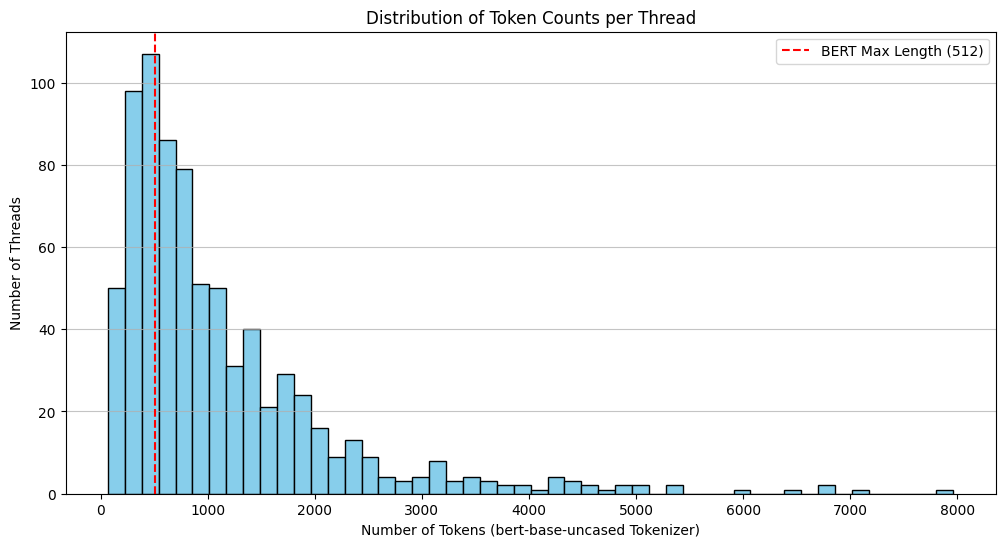

Histogram displayed successfully.


In [ ]:
jsonl_file_path = "../training_data/iac_processed.jsonl"
analyze_token_distribution(jsonl_file_path)

In [ ]:
ynacc = pd.read_json("../training_data/ynacc_processed.jsonl", lines=True, encoding="utf-8")
iac = pd.read_json("../training_data/iac_processed.jsonl", lines=True, encoding="utf-8")
print(
    f"YNACC dataset balance: {ynacc['label'].value_counts()}, {ynacc['label'].value_counts(normalize=True)}"
)
print(
    f"IAC dataset balance: {iac['label'].value_counts()}, {iac['label'].value_counts(normalize=True)}"
)

YNACC dataset balance: label
1    963
0    919
Name: count, dtype: int64, label
1    0.51169
0    0.48831
Name: proportion, dtype: float64
IAC dataset balance: label
1    613
0    156
Name: count, dtype: int64, label
1    0.797139
0    0.202861
Name: proportion, dtype: float64


# Reddit Datasets Preparation

In [ ]:
import json


def remove_label_key(input_file, output_file):
    """
    Removes the 'label' key and its value from each JSON object in a .jsonl file.

    Args:
        input_file (str): Path to the input .jsonl file.
        output_file (str): Path to the output .jsonl file where modified objects will be written.
    """
    with open(input_file, "r", encoding="utf-8") as infile, open(
        output_file, "w", encoding="utf-8"
    ) as outfile:
        for line in infile:
            try:
                data = json.loads(line)
                if "label" in data:
                    del data["label"]
                outfile.write(json.dumps(data) + "\n")
            except json.JSONDecodeError as e:
                print(f"Skipping malformed JSON line: {line.strip()} - Error: {e}")

In [6]:
import json
import re


def find_max_authors(jsonl_file_path):
    """
    Find the maximum number of authors in the dataset by analyzing [authornumber] patterns.

    Args:
        jsonl_file_path (str): Path to the input JSONL file.

    Returns:
        int: Maximum author number found + 1 (since numbering starts at 0)
    """
    max_author_num = -1

    with open(jsonl_file_path, "r", encoding="utf-8") as f:
        for line in f:
            data = json.loads(line)
            text = data.get("text", "")

            # Find all [authornumber] patterns
            author_matches = re.findall(r"\[author(\d+)\]", text)
            if author_matches:
                # Convert to integers and find the maximum
                author_numbers = [int(match) for match in author_matches]
                current_max = max(author_numbers)
                max_author_num = max(max_author_num, current_max)

    return max_author_num + 1  # +1 because numbering starts at 0

In [ ]:
# Find maximum number of authors
max_authors = find_max_authors("../data/testing_threads.jsonl")
print(f"Maximum number of authors found: {max_authors}")

Maximum number of authors found: 9


In [8]:
import json
import pandas as pd
import numpy as np
import re


def split_text_by_authors(text, max_comments=27):
    """
    Split text by [authornumber] patterns and return a list of comments.

    Args:
        text (str): The text to split
        max_comments (int): Maximum number of comment columns to create

    Returns:
        list: List of comments, padded with empty strings if needed
    """
    # Clean the text first
    text = re.sub(r"\s+", " ", text).strip()

    # Split by [authornumber] pattern
    parts = re.split(r"\[author\d+\]", text)

    # Remove empty parts and strip whitespace
    comments = [part.strip() for part in parts if part.strip()]

    # Pad with empty strings to reach max_comments length
    while len(comments) < max_comments:
        comments.append("")

    # Truncate if we have more comments than expected
    return comments[:max_comments]

In [ ]:
# Read the JSONL file
data = []
with open("../data/testing_threads.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

print(f"Loaded {len(data)} objects from testing_threads.jsonl")


# Convert to DataFrame
df = pd.DataFrame(data)

# Select only the required columns
df_subset = df[["sdid", "text"]].copy()

# Split text into separate comment columns
comment_data = []
for _, row in df_subset.iterrows():
    comments = split_text_by_authors(row["text"], max_comments=27)
    comment_row = {"sdid": row["sdid"]}
    for i in range(27):
        comment_row[f"comment{i}"] = comments[i]
    comment_data.append(comment_row)

# Create new DataFrame with comment columns
df_comments = pd.DataFrame(comment_data)

# Shuffle the data randomly
df_shuffled = df_comments.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV
output_path = "../data/testing_threads_random.csv"
df_shuffled.to_csv(output_path, index=False)

print(f"Successfully created CSV file at: {output_path}")
print(f"CSV contains {len(df_shuffled)} rows with columns: {list(df_shuffled.columns)}")
print(f"First few rows:")
print(df_shuffled.head())

Loaded 220 objects from testing_threads.jsonl
Successfully created CSV file at: ../data/testing_threads_random.csv
CSV contains 220 rows with columns: ['sdid', 'comment0', 'comment1', 'comment2', 'comment3', 'comment4', 'comment5', 'comment6', 'comment7', 'comment8', 'comment9', 'comment10', 'comment11', 'comment12', 'comment13', 'comment14', 'comment15', 'comment16', 'comment17', 'comment18', 'comment19', 'comment20', 'comment21', 'comment22', 'comment23', 'comment24', 'comment25', 'comment26']
First few rows:
      sdid                                           comment0  \
0  fpbdhj3  If you could turn any movie into a porno but k...   
1  fpc96gr                                          Cute Sana   
2  fpap1xt  [LF] Park Bench DIY [FT] Bells Looking for the...   
3  fp855pn  [LF] Catalogue Party [FT] My Catalogue! I've r...   
4  fpb9txe  The Justin Amash conundrum has an easy fix: Ra...   

                                            comment1  \
0  Tape. The whole movie is set insi

Loading data from ../data/testing_threads.jsonl...
Successfully loaded 220 entries.
Initializing tokenizer for 'bert-base-uncased'...


Token indices sequence length is longer than the specified maximum sequence length for this model (937 > 512). Running this sequence through the model will result in indexing errors


Tokenizing texts and counting tokens (this might take a moment)...

--- Token Count Distribution ---
Total threads: 220
Minimum tokens: 25
Maximum tokens: 5221
Mean tokens: 463.12
Median tokens: 225.5
Standard deviation: 672.56

--- Percentiles ---
50th percentile: 225 tokens
75th percentile: 612 tokens
90th percentile: 987 tokens
95th percentile: 1645 tokens
99th percentile: 3772 tokens
100th percentile: 5221 tokens

Threads with more than 512 tokens: 60 (27.27%)

Attempting to plot histogram (requires matplotlib)...


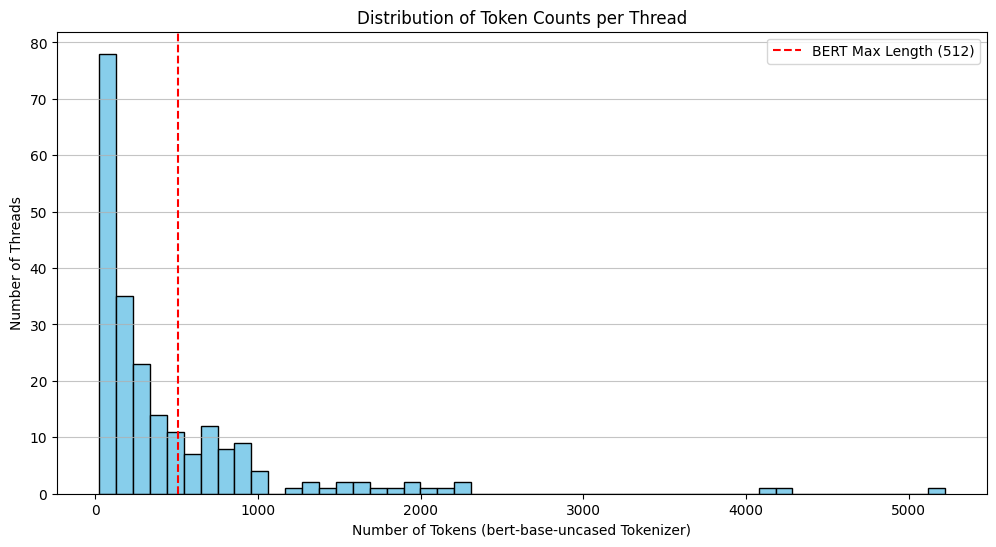

Histogram displayed successfully.


In [ ]:
jsonl_file_path = "../data/testing_threads.jsonl"
analyze_token_distribution(jsonl_file_path)

Loading data from ../data/training_threads.jsonl...
Successfully loaded 1424126 entries.
Initializing tokenizer for 'bert-base-uncased'...
Successfully loaded 1424126 entries.
Initializing tokenizer for 'bert-base-uncased'...


Token indices sequence length is longer than the specified maximum sequence length for this model (1342 > 512). Running this sequence through the model will result in indexing errors


Tokenizing texts and counting tokens (this might take a moment)...

--- Token Count Distribution ---
Total threads: 1424126
Minimum tokens: 17
Maximum tokens: 39593
Mean tokens: 286.74
Median tokens: 146.0
Standard deviation: 502.26

--- Percentiles ---
50th percentile: 146 tokens
75th percentile: 311 tokens
90th percentile: 617 tokens
95th percentile: 918 tokens
99th percentile: 2234 tokens
100th percentile: 39593 tokens

Threads with more than 512 tokens: 190495 (13.38%)

Attempting to plot histogram (requires matplotlib)...

--- Token Count Distribution ---
Total threads: 1424126
Minimum tokens: 17
Maximum tokens: 39593
Mean tokens: 286.74
Median tokens: 146.0
Standard deviation: 502.26

--- Percentiles ---
50th percentile: 146 tokens
75th percentile: 311 tokens
90th percentile: 617 tokens
95th percentile: 918 tokens
99th percentile: 2234 tokens
100th percentile: 39593 tokens

Threads with more than 512 tokens: 190495 (13.38%)

Attempting to plot histogram (requires matplotlib)...


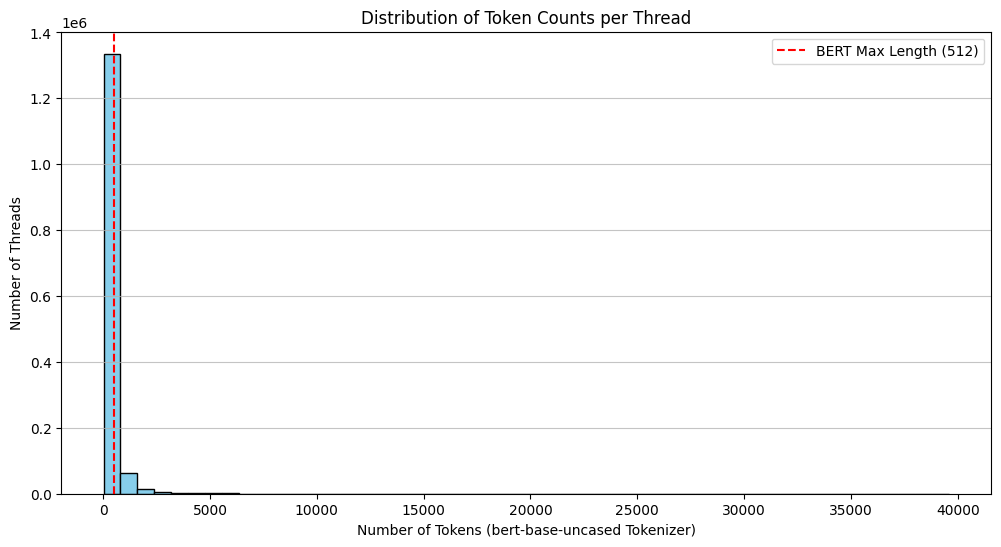

Histogram displayed successfully.


In [ ]:
jsonl_file_path = "../data/training_threads.jsonl"
analyze_token_distribution(jsonl_file_path)

In [ ]:
import json
import pandas as pd
import numpy as np

# Read the JSONL file
data = []
with open("../data/testing_threads.jsonl", "r", encoding="utf-8") as f:
    for line in f:
        data.append(json.loads(line))

print(f"Loaded {len(data)} objects from testing_threads.jsonl")

# Convert to DataFrame
df = pd.DataFrame(data)

# Select only the required columns
df_subset = df[["sdid", "text"]].copy()

# Clean the text column by removing all formatting (newlines, tabs, extra spaces)
df_subset["text"] = df_subset["text"].str.replace(r"\s+", " ", regex=True).str.strip()

# Shuffle the data randomly
df_shuffled = df_subset.sample(frac=1, random_state=42).reset_index(drop=True)

# Save to CSV
output_path = "../data/testing_threads_random.csv"
df_shuffled.to_csv(output_path, index=False)

print(f"Successfully created CSV file at: {output_path}")
print(f"CSV contains {len(df_shuffled)} rows with columns: {list(df_shuffled.columns)}")
print(f"First few rows:")
print(df_shuffled.head())

Loaded 220 objects from testing_threads.jsonl
Successfully created CSV file at: ../data/testing_threads_random.csv
CSV contains 220 rows with columns: ['sdid', 'text']
First few rows:
      sdid                                               text
0  fpbdhj3  [author0] If you could turn any movie into a p...
1  fpc96gr  [author0] Cute Sana [author1] When is this? [a...
2  fpap1xt  [author0] [LF] Park Bench DIY [FT] Bells Looki...
3  fp855pn  [author0] [LF] Catalogue Party [FT] My Catalog...
4  fpb9txe  [author0] The Justin Amash conundrum has an ea...


In [16]:
import re
import pandas as pd


def insert_newlines_before_authors(input_csv_path, output_csv_path):
    """
    Insert \\n\\n before each occurrence of [authornumber] where number is between 0 and 9,
    except for the first occurrence in each row.

    Args:
        input_csv_path (str): Path to the input CSV file
        output_csv_path (str): Path to the output CSV file
    """
    # Read the CSV file
    df = pd.read_csv(input_csv_path)

    # Function to process each text entry
    def process_text(text):
        if pd.isna(text):
            return text

        # Find all [authornumber] patterns where number is 0-9
        pattern = r"\[author[0-9]\]"
        matches = list(re.finditer(pattern, text))

        if len(matches) <= 1:
            # If there's 0 or 1 match, no changes needed
            return text

        # Process from right to left to avoid position shifts
        modified_text = text
        for match in reversed(matches[1:]):  # Skip the first match
            start_pos = match.start()
            # Insert \n\n before the [authornumber] pattern
            modified_text = (
                modified_text[:start_pos] + "\n\n" + modified_text[start_pos:]
            )

        return modified_text

    # Apply the function to the text column
    df["text"] = df["text"].apply(process_text)

    # Save to the output CSV file
    df.to_csv(output_csv_path, index=False)
    print(f"Successfully processed CSV and saved to: {output_csv_path}")
    print(f"Processed {len(df)} rows")

In [ ]:
insert_newlines_before_authors(
    "../data/testing_threads_random.csv", "../data/testing_threads_random_modified.csv"
)

Successfully processed CSV and saved to: ../data/testing_threads_random_modified.csv
Processed 220 rows


In [ ]:
# Create annotated jsonl

import json
import csv


def filter_and_label_jsonl(jsonl_filepath, csv_filepath):
    """
    Filters objects from a JSONL file based on sdid presence in a CSV file,
    and adds a 'label' key based on a column in the CSV.

    Args:
        jsonl_filepath (str): The path to the JSONL file.
        csv_filepath (str): The path to the CSV file.

    Returns:
        list: A list of dictionaries (JSON objects) that meet the criteria,
              with an added 'label' key.
    """
    sdid_labels = {}
    try:
        with open(csv_filepath, mode="r", encoding="utf-8") as csv_file:
            csv_reader = csv.DictReader(csv_file)
            for row in csv_reader:
                sdid = row.get("sdid")
                constructiveness = row.get(
                    "constructiveness"
                )  # Assuming 'constructiveness' is the column name for Constructive/Not constructive
                if sdid and constructiveness:
                    if constructiveness == "Constructive":
                        sdid_labels[sdid] = 1
                    elif constructiveness == "Not constructive":
                        sdid_labels[sdid] = 0
    except FileNotFoundError:
        print(f"Error: CSV file not found at {csv_filepath}")
        return []
    except Exception as e:
        print(f"Error reading CSV file: {e}")
        return []

    filtered_data = []
    try:
        with open(jsonl_filepath, mode="r", encoding="utf-8") as jsonl_file:
            for line in jsonl_file:
                try:
                    obj = json.loads(line)
                    sdid = obj.get("sdid")
                    if sdid in sdid_labels:
                        obj["label"] = sdid_labels[sdid]
                        filtered_data.append(obj)
                except json.JSONDecodeError:
                    print(f"Skipping malformed JSON line: {line.strip()}")
                    continue
    except FileNotFoundError:
        print(f"Error: JSONL file not found at {jsonl_filepath}")
        return []
    except Exception as e:
        print(f"Error reading JSONL file: {e}")
        return []

    return filtered_data


jsonl_path = "../data/testing_threads.jsonl"
csv_path = "../training_data/reddit_annotated.csv"
# Now run the function
result = filter_and_label_jsonl(jsonl_path, csv_path)

# Save the result to a new JSONL file
output_jsonl_path = "../training_data/reddit_val.jsonl"
with open(output_jsonl_path, "w", encoding="utf-8") as output_file:
    for item in result:
        output_file.write(json.dumps(item) + "\n")

In [2]:
# Shuffle the objects in ../training_data/reddit_val.jsonl and move the first 100 to ../training_data/reddit_test.jsonl
import json
import random

# Load the validation data
with open("../training_data/reddit_val.jsonl", "r", encoding="utf-8") as val_file:
    val_data = [json.loads(line) for line in val_file]

# Shuffle the data
random.shuffle(val_data)

# Select the first 100 items for the test set
test_data = val_data[:100]

# Save the test data to a new JSONL file
with open("../training_data/reddit_test.jsonl", "w", encoding="utf-8") as test_file:
    for item in test_data:
        test_file.write(json.dumps(item) + "\n")
# Remove the test data from the validation set
val_data = val_data[100:]
# Save the remaining validation data back to the validation file
with open("../training_data/reddit_val.jsonl", "w", encoding="utf-8") as val_file:
    for item in val_data:
        val_file.write(json.dumps(item) + "\n")

In [3]:
# print label distribution of ../training_data/reddit_val.jsonl
import json

with open("../training_data/reddit_val.jsonl", "r", encoding="utf-8") as val_file:
    val_data = [json.loads(line) for line in val_file]

label_counts = {}
for item in val_data:
    label = item.get("label")
    if label is not None:
        label_counts[label] = label_counts.get(label, 0) + 1

print("Label distribution in ../training_data/reddit_val.jsonl:")
for label, count in label_counts.items():
    print(f"Label {label}: {count}")
# print label distribution of ../training_data/reddit_test.jsonl
with open("../training_data/reddit_test.jsonl", "r", encoding="utf-8") as test_file:
    test_data = [json.loads(line) for line in test_file]

label_counts = {}
for item in test_data:
    label = item.get("label")
    if label is not None:
        label_counts[label] = label_counts.get(label, 0) + 1

print("Label distribution in ../training_data/reddit_test.jsonl:")
for label, count in label_counts.items():
    print(f"Label {label}: {count}")

Label distribution in ../training_data/reddit_val.jsonl:
Label 1: 61
Label 0: 23
Label distribution in ../training_data/reddit_test.jsonl:
Label 0: 29
Label 1: 71


In [5]:
import pandas as pd

df = pd.read_csv("../training_data/reddit_annotated.csv")
print(df["constructiveness"].value_counts())

# Shuffle the DataFrame randomly
df = df.sample(frac=1, random_state=42).reset_index(drop=True)
# Split the DataFrame into two parts for further analysis, the first 110 rows and the rest
df_1 = df[:110]
df_2 = df[110:]
print(df_1["constructiveness"].value_counts())
print(df_2["constructiveness"].value_counts())

constructiveness
Constructive        132
Not constructive     52
Name: count, dtype: int64
constructiveness
Constructive        64
Not constructive    25
Name: count, dtype: int64
constructiveness
Constructive        68
Not constructive    27
Name: count, dtype: int64
